# BT5153 Group 4 - Modeling Pipeline (No Insights/Visualization Write-up)

This notebook is designed to cover modeling, feature analysis, and evaluation artifacts for the final report rubric using the cleaned dataset already produced.

Scope intentionally excludes business insight narration and advanced visualization polish (handled by teammate).

## 1) Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

SEED = 42
MAX_ROWS = 300_000
MAX_BAD_SAMPLE = 50_000
RUN_BERTOPIC = False

DATA_FILE = Path('electronics_filtered.csv')
META_FILE = Path('electronics_metadata.csv')

assert DATA_FILE.exists(), 'Missing electronics_filtered.csv in workspace root'
assert META_FILE.exists(), 'Missing electronics_metadata.csv in workspace root'

print('Found files:', DATA_FILE, META_FILE)
print('Row cap for stable execution:', MAX_ROWS)

Found files: electronics_filtered.csv electronics_metadata.csv
Row cap for stable execution: 300000


## 2) Load Data and Build Labels

In [2]:
pdf = pd.read_csv(
    DATA_FILE,
    nrows=MAX_ROWS,
    dtype={'asin': 'string'},
    usecols=['asin', 'overall', 'reviewText', 'summary', 'verified']
 )

pdf['summary'] = pdf['summary'].fillna('').astype(str)
pdf['reviewText'] = pdf['reviewText'].fillna('').astype(str)
pdf['verified'] = pdf['verified'].fillna(False).astype(bool)
pdf['text'] = (pdf['summary'] + ' ' + pdf['reviewText']).str.strip()
pdf['word_len'] = pdf['reviewText'].str.count(r'\S+')

# Rating-driven labels (no separate sentiment model needed).
pdf['is_bad_review'] = pdf['overall'] <= 2
pdf['is_good_review'] = pdf['overall'] >= 4

print('Shape:', pdf.shape)
print('Bad review rate (overall<=2):', round(pdf['is_bad_review'].mean(), 4))
print('Good review rate (overall>=4):', round(pdf['is_good_review'].mean(), 4))

Shape: (300000, 9)
Bad review rate (overall<=2): 0.1861
Good review rate (overall>=4): 0.7278


## 3) Feature Analysis (No business insight write-up)

In [3]:
feature_summary = (
    pdf.groupby('is_bad_review', as_index=False)
       .agg(
           n=('is_bad_review', 'size'),
           avg_word_len=('word_len', 'mean'),
           med_word_len=('word_len', 'median'),
           verified_rate=('verified', 'mean')
       )
)
feature_summary['group'] = feature_summary['is_bad_review'].map({True: 'bad_review(overall<=2)', False: 'non_bad_review(overall>2)'})
feature_summary['verified_rate'] = feature_summary['verified_rate'].round(4)
feature_summary['avg_word_len'] = feature_summary['avg_word_len'].round(2)
print('Basic feature summary by rating-driven review group:')
display(feature_summary[['group', 'n', 'avg_word_len', 'med_word_len', 'verified_rate']])

Basic feature summary by rating-driven review group:


,group,n,avg_word_len,med_word_len,verified_rate
0,non_bad_review(overall>2),244167,84.44,50.0,0.8611
1,bad_review(overall<=2),55833,87.10,57.0,0.8188


In [4]:
# Frequent terms in bad vs non-bad reviews (rating-driven, no supervised sentiment model).
sample_for_terms = pdf.sample(n=min(120000, len(pdf)), random_state=SEED).copy()

vec = CountVectorizer(min_df=10, max_df=0.8, ngram_range=(1, 2), stop_words='english')
X_terms = vec.fit_transform(sample_for_terms['text'])
feature_names = np.array(vec.get_feature_names_out())

is_bad = sample_for_terms['is_bad_review'].to_numpy()
bad_counts = np.asarray(X_terms[is_bad].sum(axis=0)).ravel()
non_bad_counts = np.asarray(X_terms[~is_bad].sum(axis=0)).ravel()

top_bad_idx = np.argsort(bad_counts)[-20:][::-1]
top_non_bad_idx = np.argsort(non_bad_counts)[-20:][::-1]

top_terms_df = pd.DataFrame({
    'bad_review_top_terms': feature_names[top_bad_idx],
    'non_bad_review_top_terms': feature_names[top_non_bad_idx],
})
display(top_terms_df)

,bad_review_top_terms,non_bad_review_top_terms
0,work,great
1,just,good
2,product,use
3,use,just
4,good,like
5,like,works
6,time,sound
7,don,price
8,buy,quality
9,quality,product


## 4) Product-Level Rating Summary (No Sentiment Model)

In [5]:
product_stats = (
    pdf.groupby('asin', as_index=False)
      .agg(
          reviews=('overall', 'size'),
          avg_rating=('overall', 'mean'),
          bad_review_rate=('is_bad_review', 'mean'),
          good_review_rate=('is_good_review', 'mean'),
          verified_rate=('verified', 'mean')
      )
)

meta = pd.read_csv(
    META_FILE,
    dtype={'asin': 'string'},
    usecols=['asin', 'title', 'brand', 'avg_rating', 'review_count']
 )

product_stats = product_stats.merge(
    meta[['asin', 'title', 'brand']],
    on='asin',
    how='left'
 )

product_stats['avg_rating'] = product_stats['avg_rating'].round(3)
product_stats['bad_review_rate'] = product_stats['bad_review_rate'].round(3)
product_stats['good_review_rate'] = product_stats['good_review_rate'].round(3)
product_stats['verified_rate'] = product_stats['verified_rate'].round(3)

product_stats['quality_band'] = np.select(
    [product_stats['avg_rating'] <= 2.0, product_stats['avg_rating'] >= 4.0],
    ['bad_product', 'good_product'],
    default='mid_product'
 )

quality_summary = product_stats['quality_band'].value_counts().rename_axis('quality_band').reset_index(name='n_products')
print('Product quality band counts:')
display(quality_summary)

Product quality band counts:


,quality_band,n_products
0,good_product,453
1,mid_product,400


In [6]:
print('Top bad products (avg_rating <= 2):')
bad_products = product_stats.loc[product_stats['avg_rating'] <= 2.0].copy()
bad_products = bad_products.sort_values(['avg_rating', 'reviews', 'bad_review_rate'], ascending=[True, False, False])
display(bad_products[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'bad_review_rate', 'verified_rate']].head(30))

print('Top good products (avg_rating >= 4):')
good_products = product_stats.loc[product_stats['avg_rating'] >= 4.0].copy()
good_products = good_products.sort_values(['avg_rating', 'reviews'], ascending=[False, False])
display(good_products[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'good_review_rate', 'verified_rate']].head(30))

Top bad products (avg_rating <= 2):


,asin,title,brand,reviews,avg_rating,bad_review_rate,verified_rate


Top good products (avg_rating >= 4):


,asin,title,brand,reviews,avg_rating,good_review_rate,verified_rate
47,B0000DYV9N,Pelican 1500 Camera Case With Foam (Silver),Pelican,231,4.922,0.991,0.948
48,B0000DYV9N,Pelican 1500 Camera Case With Foam (Silver),Pelican,231,4.922,0.991,0.948
157,B000WU2LXC,"ARCTIC MX-2 - Thermal Compound Paste, Carbon B...",ARCTIC,500,4.792,0.956,0.900
370,B005C50H2Y,Nikon AF-S DX Micro-NIKKOR 40mm f/2.8G Close-u...,Nikon,221,4.792,0.968,0.851
330,B004EBX5GW,Mediabridge ULTRA Series RCA Y-Adapter (12 Inc...,Mediabridge,269,4.788,0.963,0.974
440,B007JPCL88,TiVo Premiere 500 GB DVR (Old Version) - Digit...,TiVo,500,4.774,0.986,0.044
268,B002EEP3MK,"OPPO BDP-83 Blu-ray Disc Player with SACD, DV...",OPPO Digital,295,4.773,0.942,0.759
632,B00K4NVRRI,The Friendly Swede Replaceable Micro-Knit Tip ...,The Friendly Swede,500,4.768,0.956,0.954
204,B0017I3K9M,Viewsonics VSIS-EU Cable TV Ground Loop Isolator,Viewsonics,500,4.762,0.938,0.958
234,B001MX5YWI,Crucial 8GB Kit (4GBx2) DDR3 1066 MT/s (PC3-85...,Crucial,500,4.754,0.940,0.956


In [7]:
# Artifact for teammate: product-level table with names and quality labels.
product_quality_artifact = product_stats[[
    'asin', 'title', 'brand', 'reviews', 'avg_rating', 'bad_review_rate', 'good_review_rate', 'quality_band'
]].copy()

product_quality_artifact = product_quality_artifact.sort_values(
    ['quality_band', 'avg_rating', 'reviews'],
    ascending=[True, True, False]
).reset_index(drop=True)

print('Product quality artifact preview (ready for teammate use):')
display(product_quality_artifact.head(30))

Product quality artifact preview (ready for teammate use):


,asin,title,brand,reviews,avg_rating,bad_review_rate,good_review_rate,quality_band
0,B005HJWWW8,Compatible 2 in 1 Charger and Headphones Adapt...,EldHus,500,4.000,0.170,0.738,good_product
1,B01CCMUN8C,EDUP WiFi Adapter ac600Mbps Wireless USB Adapt...,EDUP,460,4.000,0.215,0.737,good_product
2,B009Y9O6NK,Apple iPad mini Smart Cover (Light Gray) - MD9...,Apple,346,4.000,0.188,0.728,good_product
3,B00BCPH3YS,Samsung PN64F8500 64-Inch 1080p 600Hz 3D Smart...,Samsung,373,4.003,0.212,0.740,good_product
4,B00114ZT78,Board Dudes 18&quot; x 22&quot; Magnetic Dry E...,The Board Dudes,217,4.005,0.161,0.737,good_product
5,B00PC9HFO8,Dell Ultra HD 4k Monitor P2715Q 27-Inch Screen...,Dell,500,4.006,0.180,0.726,good_product
6,B01EC7AGVE,COMISO Portable Bluetooth 360&deg; Speaker wit...,COMISO,476,4.008,0.204,0.742,good_product
7,B00064V6RG,SanDisk ImageMate 12-in-1 USB 2.0 Flash Memory...,SanDisk,277,4.011,0.184,0.762,good_product
8,B0170MA9VU,"iPad Pro Case, SUPCASE [Heavy Duty] Apple iPad...",SUPCASE,237,4.013,0.169,0.730,good_product
9,B0000A1VS3,Nikon 25604 UC-E6 USB Cable,Nikon,433,4.014,0.206,0.760,good_product


## 5) Topic Modeling on Bad Reviews (overall <= 2)

In [8]:
bad_reviews = pdf.loc[pdf['is_bad_review'], 'text'].dropna()
bad_reviews = bad_reviews[bad_reviews.str.len() > 30]

bad_sample = bad_reviews.sample(n=min(MAX_BAD_SAMPLE, len(bad_reviews)), random_state=SEED)
print('Bad review sample size for topic models:', len(bad_sample))

Bad review sample size for topic models: 50000


In [9]:
n_topics = 12
count_vec = CountVectorizer(min_df=20, max_df=0.7, stop_words='english')
X_bad_count = count_vec.fit_transform(bad_sample)

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=SEED,
    learning_method='batch',
    max_iter=20
)
lda.fit(X_bad_count)

tfidf_vec = TfidfVectorizer(min_df=20, max_df=0.7, stop_words='english')
X_bad_tfidf = tfidf_vec.fit_transform(bad_sample)

nmf = NMF(n_components=n_topics, random_state=SEED, init='nndsvda', max_iter=300)
nmf.fit(X_bad_tfidf)

print('LDA and NMF fitted on bad reviews.')

LDA and NMF fitted on bad reviews.


In [10]:
def get_top_words(model, feature_names, n_top_words=12):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_idx = np.argsort(topic)[-n_top_words:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

lda_topics = get_top_words(lda, count_vec.get_feature_names_out())
nmf_topics = get_top_words(nmf, tfidf_vec.get_feature_names_out())

lda_topics_df = pd.DataFrame({'topic_id': range(len(lda_topics)), 'top_words': [' | '.join(t) for t in lda_topics]})
nmf_topics_df = pd.DataFrame({'topic_id': range(len(nmf_topics)), 'top_words': [' | '.join(t) for t in nmf_topics]})

print('LDA Topics')
display(lda_topics_df)
print('NMF Topics')
display(nmf_topics_df)

LDA Topics


,topic_id,top_words
0,0,battery | charge | player | time | ipod | use ...
1,1,case | ipad | keyboard | fit | like | does | c...
2,2,camera | tv | picture | video | quality | pict...
3,3,drive | computer | windows | usb | work | soft...
4,4,months | product | working | amazon | worked |...
5,5,screen | product | plastic | like | item | box...
6,6,sound | quality | good | speaker | speakers | ...
7,7,headphones | mouse | ear | use | pair | good |...
8,8,money | buy | don | waste | work | product | j...
9,9,router | support | device | wireless | connect...


NMF Topics


,topic_id,top_words
0,0,work | did | didn | does | doesn | tried | ret...
1,1,sound | quality | headphones | ear | good | pa...
2,2,working | stopped | months | worked | great | ...
3,3,camera | pictures | lens | canon | card | vide...
4,4,case | ipad | fit | screen | cover | like | do...
5,5,money | waste | don | buy | time | junk | wort...
6,6,tv | samsung | remote | screen | picture | pla...
7,7,router | drive | device | card | support | tim...
8,8,battery | charge | charger | life | charging |...
9,9,product | item | amazon | buy | return | recei...


In [11]:
# Topic diversity as proportion of unique words among all top-k topic words.
def topic_diversity(topics, top_k=10):
    words = []
    for t in topics:
        words.extend(t[:top_k])
    return len(set(words)) / len(words)

div_lda = topic_diversity(lda_topics, top_k=10)
div_nmf = topic_diversity(nmf_topics, top_k=10)

topic_quality_df = pd.DataFrame([
    {'model': 'LDA', 'topic_diversity@10': div_lda},
    {'model': 'NMF', 'topic_diversity@10': div_nmf},
])
display(topic_quality_df)

,model,topic_diversity@10
0,LDA,0.808333
1,NMF,0.883333


## 6) Optional BERTopic on Bad Reviews (Run only if package available)

In [12]:
# Optional: BERTopic on bad reviews, guarded to avoid breaking notebook if package is unavailable.
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    bt_sample = bad_sample.sample(min(10000, len(bad_sample)), random_state=SEED).tolist()
    emb_model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = emb_model.encode(bt_sample, show_progress_bar=True, batch_size=256)

    topic_model = BERTopic(
        min_topic_size=100,
        calculate_probabilities=False,
        verbose=True
    )
    bt_topics, _ = topic_model.fit_transform(bt_sample, embeddings)

    bt_info = topic_model.get_topic_info().head(20)
    display(bt_info)
    print('BERTopic completed on bad-review text.')
except Exception as e:
    print('BERTopic not run:', e)
    print('This does not block the rest of the notebook.')

BERTopic not run: No module named 'bertopic'
This does not block the rest of the notebook.


## 7) Product-Level Action Artifact (for teammate handoff)

In [13]:
handoff_table = product_stats[[
    'asin', 'title', 'brand', 'reviews', 'avg_rating', 'quality_band',
    'bad_review_rate', 'good_review_rate', 'verified_rate'
]].copy()

handoff_table = handoff_table.sort_values(
    ['quality_band', 'avg_rating', 'reviews'],
    ascending=[True, True, False]
).reset_index(drop=True)

print('Handoff table counts by quality band:')
print(handoff_table['quality_band'].value_counts())
display(handoff_table.head(30))

Handoff table counts by quality band:
quality_band
good_product    453
mid_product     400
Name: count, dtype: int64


,asin,title,brand,reviews,avg_rating,quality_band,bad_review_rate,good_review_rate,verified_rate
0,B005HJWWW8,Compatible 2 in 1 Charger and Headphones Adapt...,EldHus,500,4.000,good_product,0.170,0.738,0.932
1,B01CCMUN8C,EDUP WiFi Adapter ac600Mbps Wireless USB Adapt...,EDUP,460,4.000,good_product,0.215,0.737,0.970
2,B009Y9O6NK,Apple iPad mini Smart Cover (Light Gray) - MD9...,Apple,346,4.000,good_product,0.188,0.728,0.945
3,B00BCPH3YS,Samsung PN64F8500 64-Inch 1080p 600Hz 3D Smart...,Samsung,373,4.003,good_product,0.212,0.740,0.694
4,B00114ZT78,Board Dudes 18&quot; x 22&quot; Magnetic Dry E...,The Board Dudes,217,4.005,good_product,0.161,0.737,0.917
5,B00PC9HFO8,Dell Ultra HD 4k Monitor P2715Q 27-Inch Screen...,Dell,500,4.006,good_product,0.180,0.726,0.866
6,B01EC7AGVE,COMISO Portable Bluetooth 360&deg; Speaker wit...,COMISO,476,4.008,good_product,0.204,0.742,0.878
7,B00064V6RG,SanDisk ImageMate 12-in-1 USB 2.0 Flash Memory...,SanDisk,277,4.011,good_product,0.184,0.762,0.567
8,B0170MA9VU,"iPad Pro Case, SUPCASE [Heavy Duty] Apple iPad...",SUPCASE,237,4.013,good_product,0.169,0.730,0.970
9,B0000A1VS3,Nikon 25604 UC-E6 USB Cable,Nikon,433,4.014,good_product,0.206,0.760,0.956


## 8) Simple Product Quality Dashboard (Table-based)

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

dash_df = product_stats.copy()
dash_df['title'] = dash_df['title'].fillna('')
dash_df['brand'] = dash_df['brand'].fillna('')

brand_options = ['ALL'] + sorted([b for b in dash_df['brand'].astype(str).replace('', np.nan).dropna().unique()][:300])
quality_options = ['ALL', 'bad_product', 'mid_product', 'good_product']

brand_dd = widgets.Dropdown(options=brand_options, value='ALL', description='Brand:')
quality_dd = widgets.Dropdown(options=quality_options, value='ALL', description='Quality:')
topn = widgets.IntSlider(value=10, min=5, max=30, step=1, description='Top N:')
sort_by = widgets.Dropdown(
    options=['avg_rating_asc', 'avg_rating_desc', 'bad_review_rate_desc', 'reviews_desc'],
    value='avg_rating_asc',
    description='Sort:'
)
out = widgets.Output()

def render(_=None):
    with out:
        clear_output(wait=True)
        d = dash_df.copy()

        if brand_dd.value != 'ALL':
            d = d[d['brand'].astype(str) == brand_dd.value]
        if quality_dd.value != 'ALL':
            d = d[d['quality_band'] == quality_dd.value]

        if len(d) == 0:
            print('No rows for this filter.')
            return

        if sort_by.value == 'avg_rating_asc':
            d = d.sort_values(['avg_rating', 'reviews'], ascending=[True, False])
        elif sort_by.value == 'avg_rating_desc':
            d = d.sort_values(['avg_rating', 'reviews'], ascending=[False, False])
        elif sort_by.value == 'bad_review_rate_desc':
            d = d.sort_values(['bad_review_rate', 'reviews'], ascending=[False, False])
        else:
            d = d.sort_values(['reviews', 'avg_rating'], ascending=[False, False])

        view = d[['asin', 'title', 'brand', 'reviews', 'avg_rating', 'quality_band', 'bad_review_rate', 'good_review_rate', 'verified_rate']].head(topn.value).copy()
        view['avg_rating'] = view['avg_rating'].round(3)
        view['bad_review_rate'] = view['bad_review_rate'].round(3)
        view['good_review_rate'] = view['good_review_rate'].round(3)
        view['verified_rate'] = view['verified_rate'].round(3)
        display(view)

brand_dd.observe(render, names='value')
quality_dd.observe(render, names='value')
topn.observe(render, names='value')
sort_by.observe(render, names='value')

display(widgets.HBox([brand_dd, quality_dd]))
display(widgets.HBox([sort_by, topn]))
display(out)
render()

Output()

## 9) Rubric Checklist Artifact (Rating-Driven Pipeline)

In [15]:
rubric_checklist = pd.DataFrame([
    ['Clarity/completeness', 'Data loading, rating-based grouping, and product-level aggregation documented'],
    ['Appropriate modeling scope', 'No redundant sentiment classifier; uses ground-truth rating thresholds directly'],
    ['Coherence with hypotheses', 'Bad-product identification and complaint-theme modeling aligned with objective'],
    ['Real-world usefulness', 'Product-level handoff table with avg rating, quality band, and bad-review rate'],
    ['Concise summarization support', 'Quality-band counts, top bad/good product tables, and dashboard outputs generated'],
    ['Advantages/limitations discussion support', 'Topic-model outputs on bad reviews and optional BERTopic fallback documented']
], columns=['Rubric item', 'Notebook evidence'])
display(rubric_checklist)

,Rubric item,Notebook evidence
0,Clarity/completeness,"Data loading, rating-based grouping, and produ..."
1,Appropriate modeling scope,No redundant sentiment classifier; uses ground...
2,Coherence with hypotheses,Bad-product identification and complaint-theme...
3,Real-world usefulness,"Product-level handoff table with avg rating, q..."
4,Concise summarization support,"Quality-band counts, top bad/good product tabl..."
5,Advantages/limitations discussion support,Topic-model outputs on bad reviews and optiona...


## 10) Baseline Insights
> Quick, non-interpretive insights generated from rating-driven outputs.

In [16]:
insights_starter = pd.DataFrame([
    ['Sample rows used', len(pdf)],
    ['Unique products in sample', int(pdf['asin'].nunique())],
    ['Bad review rate (overall<=2)', round(float(pdf['is_bad_review'].mean()), 4)],
    ['Good review rate (overall>=4)', round(float(pdf['is_good_review'].mean()), 4)],
    ['Products labeled bad_product (avg<=2)', int((product_stats['quality_band'] == 'bad_product').sum())],
    ['Products labeled good_product (avg>=4)', int((product_stats['quality_band'] == 'good_product').sum())],
    ['Topic diversity@10 (LDA)', round(float(div_lda), 4)],
    ['Topic diversity@10 (NMF)', round(float(div_nmf), 4)],
], columns=['Metric', 'Value'])

display(insights_starter)

print('Top 10 brands by bad review rate (min 200 reviews in sample):')
brand_insights = (
    pdf.groupby('brand', as_index=False) if 'brand' in pdf.columns else None
)
if brand_insights is None:
    tmp = product_stats.groupby('brand', as_index=False).agg(
        products=('asin', 'nunique'),
        total_reviews=('reviews', 'sum'),
        avg_bad_rate=('bad_review_rate', 'mean'),
        avg_rating=('avg_rating', 'mean')
    )
else:
    tmp = brand_insights

brand_summary = (
    product_stats.groupby('brand', as_index=False)
      .agg(
          products=('asin', 'nunique'),
          total_reviews=('reviews', 'sum'),
          avg_bad_rate=('bad_review_rate', 'mean'),
          avg_rating=('avg_rating', 'mean')
      )
      .query('total_reviews >= 200')
      .sort_values(['avg_bad_rate', 'total_reviews'], ascending=[False, False])
      .head(10)
      .reset_index(drop=True)
 )
brand_summary['avg_bad_rate'] = brand_summary['avg_bad_rate'].round(3)
brand_summary['avg_rating'] = brand_summary['avg_rating'].round(3)
display(brand_summary)

,Metric,Value
0,Sample rows used,300000.0000
1,Unique products in sample,814.0000
2,Bad review rate (overall<=2),0.1861
3,Good review rate (overall>=4),0.7278
4,Products labeled bad_product (avg<=2),0.0000
5,Products labeled good_product (avg>=4),453.0000
6,Topic diversity@10 (LDA),0.8083
7,Topic diversity@10 (NMF),0.8833


Top 10 brands by bad review rate (min 200 reviews in sample):


,brand,products,total_reviews,avg_bad_rate,avg_rating
0,Tagital,1,317,0.688,2.161
1,JLAB,1,500,0.550,2.610
2,Jabra,1,335,0.549,2.633
3,Zeikos,1,364,0.514,2.775
4,Besdata,1,500,0.500,2.742
5,Lexar,1,500,0.496,2.908
6,Access HD,1,266,0.492,2.684
7,XO Vision,1,500,0.458,2.784
8,Blue Donuts,1,500,0.450,2.864
9,Griffin Technology,2,1252,0.438,2.961


## 11) Visualization Starter


> Basic plots only; teammate can improve narrative, style, and interactivity.

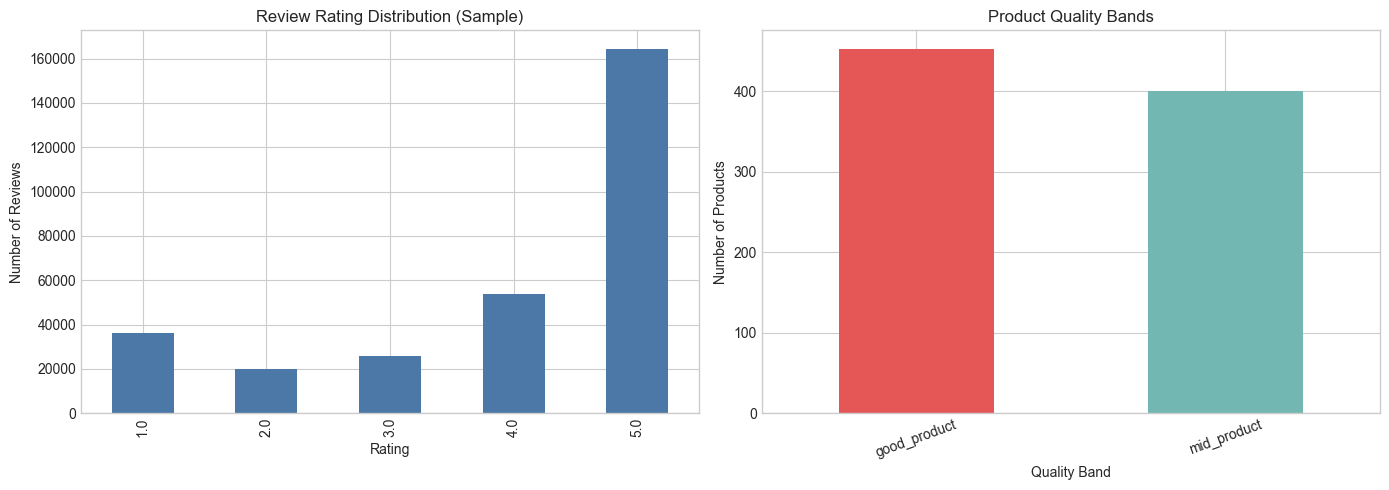

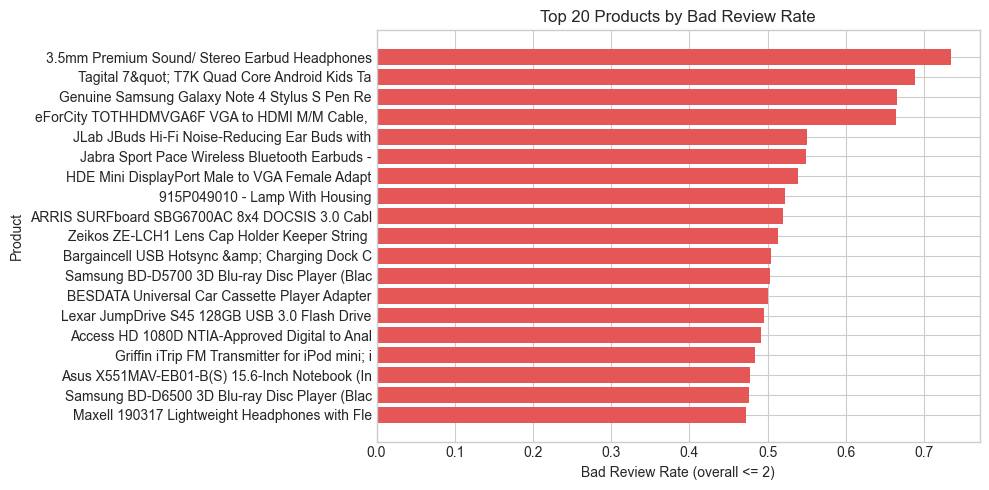

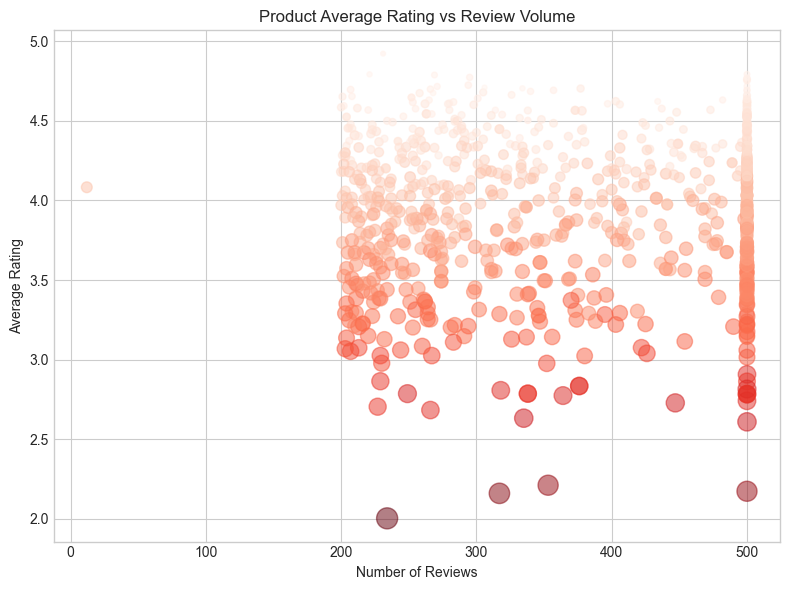

In [17]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1) Overall rating distribution
pdf['overall'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4C78A8')
ax[0].set_title('Review Rating Distribution (Sample)')
ax[0].set_xlabel('Rating')
ax[0].set_ylabel('Number of Reviews')

# 2) Product quality bands
quality_counts = product_stats['quality_band'].value_counts()
quality_counts.plot(kind='bar', ax=ax[1], color=['#E45756', '#72B7B2', '#54A24B'])
ax[1].set_title('Product Quality Bands')
ax[1].set_xlabel('Quality Band')
ax[1].set_ylabel('Number of Products')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
top_bad = product_stats.sort_values('bad_review_rate', ascending=False).head(20).copy()
top_bad = top_bad.sort_values('bad_review_rate', ascending=True)
labels = top_bad['title'].fillna(top_bad['asin']).astype(str).str.slice(0, 45)
ax.barh(labels, top_bad['bad_review_rate'], color='#E45756')
ax.set_title('Top 20 Products by Bad Review Rate')
ax.set_xlabel('Bad Review Rate (overall <= 2)')
ax.set_ylabel('Product')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    product_stats['reviews'],
    product_stats['avg_rating'],
    s=(product_stats['bad_review_rate'] * 300 + 10),
    alpha=0.5,
    c=product_stats['bad_review_rate'],
    cmap='Reds'
 )
ax.set_title('Product Average Rating vs Review Volume')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plt.show()